In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [7]:
PROJECT_ROOT = Path.cwd().parent
data_dir = PROJECT_ROOT / "all_datasets" / "optical_recognition_dataset"
columns = [f"pixel_{i}" for i in range(64)] + ["label"]
train = pd.read_csv(data_dir / "optdigits.tra", header=None, names=columns)
test = pd.read_csv(data_dir / "optdigits.tes", header=None, names=columns)

In [8]:
# The dataset ships with an official training file and an official test file.
# Keep the official test file untouched while exploring the compression choice.
X_dev = train.drop(columns="label") / 16.0
y_dev = train["label"]
X_test = test.drop(columns="label") / 16.0
y_test = test["label"]

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev
)

# Development baseline: all 64 features, evaluated on validation data.
baseline = LogisticRegression(max_iter=2000)
baseline.fit(X_fit, y_fit)
baseline_valid = baseline.predict(X_valid)
print(
    "64-feature validation accuracy:",
    round(accuracy_score(y_valid, baseline_valid), 4),
)

64-feature validation accuracy: 0.955


In [9]:
# Compare compression budgets only on development validation data.
for retained_variance in [0.90, 0.95, 0.99]:
    candidate = Pipeline([
        ("pca", PCA(n_components=retained_variance, svd_solver="full")),
        ("model", LogisticRegression(max_iter=2000)),
    ])
    candidate.fit(X_fit, y_fit)
    valid_pred = candidate.predict(X_valid)
    pca = candidate.named_steps["pca"]
    print(
        f"{retained_variance:.0%} variance:",
        "components=", pca.n_components_,
        "validation accuracy=", round(accuracy_score(y_valid, valid_pred), 4),
    )

90% variance: components= 21 validation accuracy= 0.9487
95% variance: components= 29 validation accuracy= 0.954
99% variance: components= 41 validation accuracy= 0.9561


In [10]:
# Course policy: 95% retained variance is locked before the official test is opened.
locked_variance = 0.95
final_baseline = LogisticRegression(max_iter=2000)
final_baseline.fit(X_dev, y_dev)

final_model = Pipeline([
    ("pca", PCA(n_components=locked_variance, svd_solver="full")),
    ("model", LogisticRegression(max_iter=2000)),
])
final_model.fit(X_dev, y_dev)

baseline_test_pred = final_baseline.predict(X_test)
pca_test_pred = final_model.predict(X_test)
pca = final_model.named_steps["pca"]

print("\nFINAL LOCKED TEST")
print("full 64-feature accuracy:", round(accuracy_score(y_test, baseline_test_pred), 4))
print("PCA components kept:", pca.n_components_)
print("PCA variance retained:", round(pca.explained_variance_ratio_.sum(), 4))
print("PCA-to-logistic accuracy:", round(accuracy_score(y_test, pca_test_pred), 4))


FINAL LOCKED TEST
full 64-feature accuracy: 0.9477
PCA components kept: 29
PCA variance retained: 0.9537
PCA-to-logistic accuracy: 0.9477


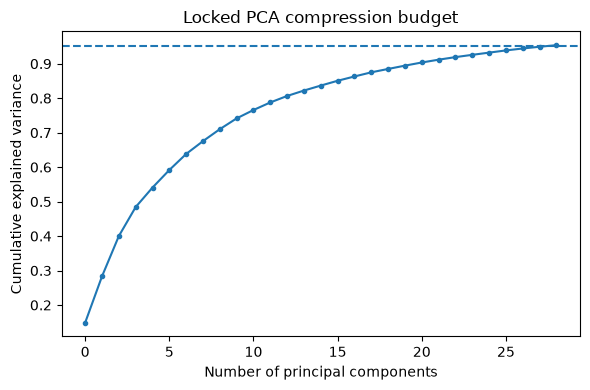

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker=".")
plt.axhline(locked_variance, linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Locked PCA compression budget")
plt.tight_layout()
plt.show()

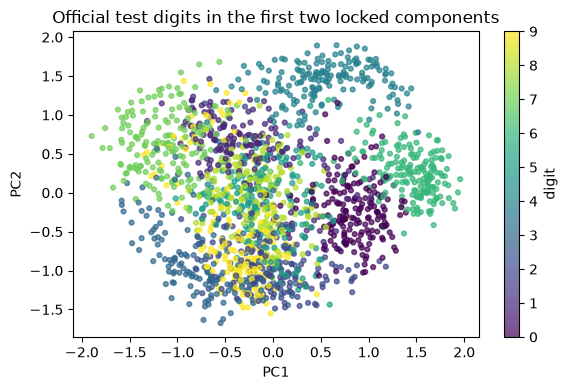

In [12]:
# This visualization is descriptive after the procedure is locked.
X_test_pca = pca.transform(X_test)
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, s=12, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Official test digits in the first two locked components")
plt.colorbar(scatter, label="digit")
plt.tight_layout()
plt.show()